,elevation_m,drainage_density_km_per_km2,storm_drain_proximity_m,historical_rainfall_intensity_mm_hr,return_period_years,is_very_low_elev,rain_x_return,land_use,soil_group,storm_drain_type,rainfall_source,dem_source,risk_class,risk_class_encoded,latitude,longitude
0,32.67,7.87,140.0,19.9,10,0,199.0,6.0,0.0,0.0,3.0,4.0,Low,1,38.853632,-77.017289
1,33.82,4.67,60.6,48.0,5,0,240.0,1.0,1.0,1.0,4.0,3.0,Low,1,21.065060,105.831464
2,19.82,6.26,282.2,74.3,5,0,371.5,0.0,0.0,3.0,3.0,1.0,Low,1,22.633800,113.957179
3,7.71,6.32,47.9,41.1,2,0,82.2,6.0,0.0,1.0,1.0,4.0,Medium,2,41.393959,2.143102
4,12.56,9.53,117.6,23.1,100,0,2310.0,2.0,0.0,1.0,1.0,0.0,Low,1,31.350399,121.515148


,elevation_m,drainage_density_km_per_km2,storm_drain_proximity_m,historical_rainfall_intensity_mm_hr,return_period_years,is_very_low_elev,rain_x_return,land_use,soil_group,storm_drain_type,rainfall_source,dem_source,risk_class,risk_class_encoded,latitude,longitude
0,21.380,6.43,75.8,24.4,100,0,2440.0,3.0,1.0,2.0,0.0,4.0,Low,1,-33.972494,151.193279
1,30.025,6.26,211.3,120.6,2,0,241.2,5.0,1.0,3.0,0.0,2.0,High,0,-22.938550,-43.299984
2,30.025,7.22,99.5,11.0,5,0,55.0,0.0,2.0,0.0,3.0,1.0,Low,1,35.709772,139.856430
3,6.640,6.26,91.4,33.1,5,0,165.5,7.0,4.0,0.0,4.0,2.0,Medium,2,38.813354,-77.080088
4,13.080,10.48,35.2,103.2,10,0,1032.0,0.0,1.0,0.0,1.0,3.0,High,0,19.090451,72.879029


X_train: (2370, 12)
X_test : (593, 12)
Train split: (1896, 12)
Val split  : (474, 12)
  EFB: 12 features → 12 bundles (100.0% compression)
  Training GBDT [softmax]: 100 iter, K=3, GOSS=on, EFB=on
  Iter    1/100 | Train loss: 0.788615 | Val loss: 0.787018
  Iter    2/100 | Train loss: 0.700882 | Val loss: 0.698688
  Iter    3/100 | Train loss: 0.658384 | Val loss: 0.654600
  Iter    4/100 | Train loss: 0.615631 | Val loss: 0.612707
  Iter    5/100 | Train loss: 0.581461 | Val loss: 0.579669
  Iter    6/100 | Train loss: 0.552685 | Val loss: 0.552394
  Iter    7/100 | Train loss: 0.505185 | Val loss: 0.506268
  Iter    8/100 | Train loss: 0.473467 | Val loss: 0.473652
  Iter    9/100 | Train loss: 0.446547 | Val loss: 0.446645
  Iter   10/100 | Train loss: 0.413888 | Val loss: 0.414509
  Iter   11/100 | Train loss: 0.385238 | Val loss: 0.386539
  Iter   12/100 | Train loss: 0.360055 | Val loss: 0.361754
  Iter   13/100 | Train loss: 0.343338 | Val loss: 0.345435
  Iter   14/100 | Train

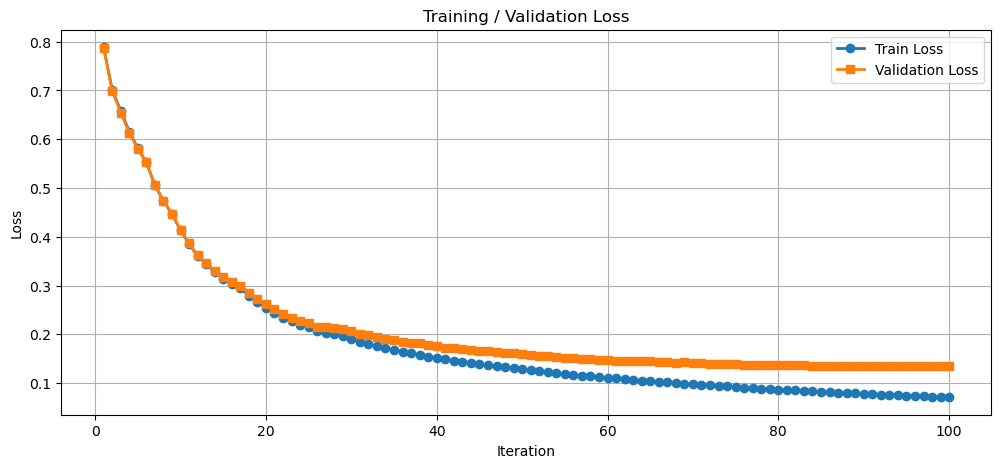

Best iteration: 96

========== METRICS ==========
Accuracy : 0.9376
F1-score : 0.9384
F2-score : 0.9378

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        79
           1       0.98      0.94      0.96       399
           2       0.85      0.93      0.89       115

    accuracy                           0.94       593
   macro avg       0.90      0.93      0.92       593
weighted avg       0.94      0.94      0.94       593



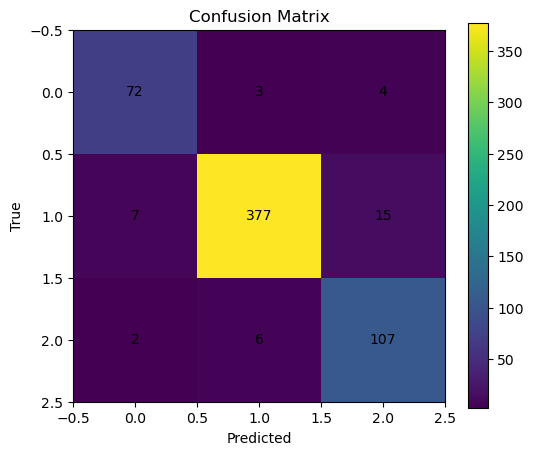

,feature,gain,split
0,elevation_m,6914.236508,626.0
3,historical_rainfall_intensity_mm_hr,4453.708561,580.0
1,drainage_density_km_per_km2,2425.340855,454.0
8,soil_group,841.286993,282.0
6,rain_x_return,647.083084,338.0
2,storm_drain_proximity_m,521.075215,435.0
5,is_very_low_elev,517.122518,18.0
10,rainfall_source,149.318501,147.0
4,return_period_years,102.363459,69.0
7,land_use,100.062376,104.0


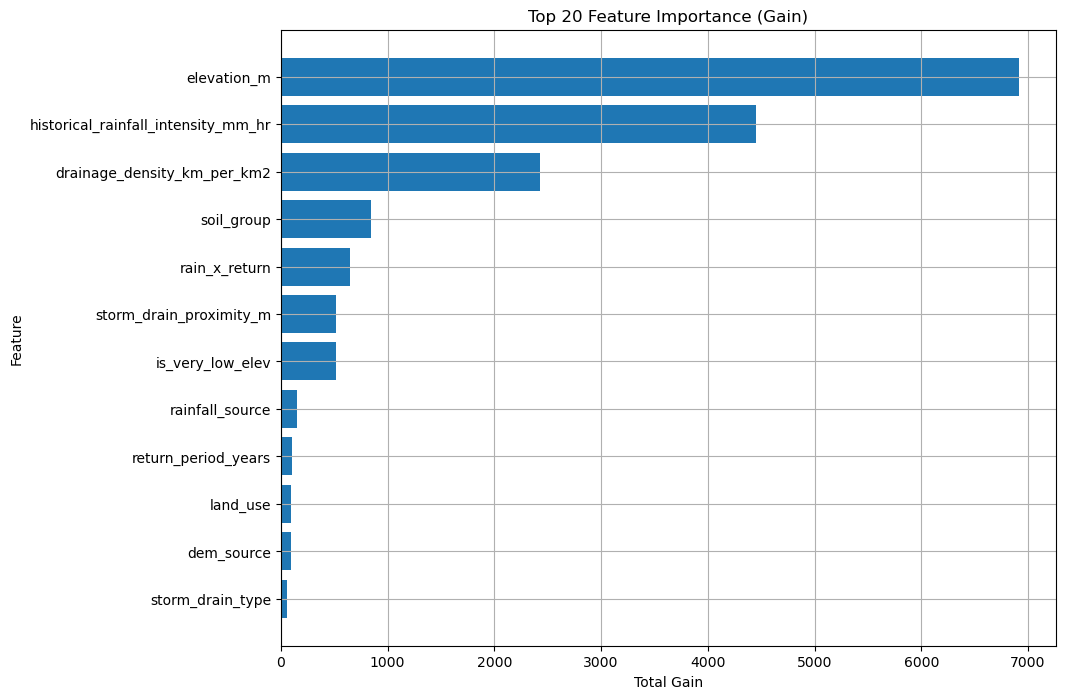

Saved model -> ../config/LGBMScratch_v2.pkl


In [1]:
# Hung_experiment_3.py
# ============================================================
# Experiment 3 — LGBM Scratch V2
# Test đầy đủ:
#   - Early stopping
#   - GOSS
#   - EFB
#   - Feature importance
#   - Validation loss
# ============================================================

import sys
sys.path.append('..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score
)

from src.model.lgbm_scratch_v2 import LGBMScratchModel


# ============================================================
# LOAD DATA
# ============================================================

train = pd.read_csv('../data/processed/tree/train.csv')
test  = pd.read_csv('../data/processed/tree/test.csv')

display(train.head())
display(test.head())


# ============================================================
# PREPARE FEATURES
# ============================================================

drop_cols = [
    'risk_class',
    'risk_class_encoded',
    'latitude',
    'longitude'
]

feature_cols = [
    c for c in train.columns
    if c not in drop_cols
]

X_train = train[feature_cols].values
y_train = train['risk_class_encoded'].values

X_test = test[feature_cols].values
y_test = test['risk_class_encoded'].values

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)


# ============================================================
# TRAIN / VALID SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print('Train split:', X_tr.shape)
print('Val split  :', X_val.shape)


# ============================================================
# BUILD MODEL
# ============================================================

model = LGBMScratchModel(

    # Boosting
    n_estimators=100,
    learning_rate=0.05,

    # Tree
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,

    # Regularization
    reg_lambda=1.0,
    reg_alpha=0.1,
    min_split_gain=0.0,

    # Sampling
    subsample=0.9,
    colsample_bytree=0.8,

    # Histogram
    max_bin=255,

    # GOSS
    use_goss=True,
    top_rate=0.2,
    other_rate=0.1,

    # EFB
    use_efb=True,
    max_conflict_rate=0.0,

    # Early stopping
    early_stopping_rounds=10,

    # Objective
    objective='softmax',

    random_state=42
)

model.build()


# ============================================================
# TRAIN
# ============================================================

model.fit(
    X_tr,
    y_tr,
    eval_set=(X_val, y_val)
)


# ============================================================
# LOSS CURVE
# ============================================================

train_loss = model.model.loss_history
val_loss   = model.model.val_loss_history

plt.figure(figsize=(12, 5))

plt.plot(
    range(1, len(train_loss) + 1),
    train_loss,
    marker='o',
    linewidth=2,
    label='Train Loss'
)

if len(val_loss) > 0:
    plt.plot(
        range(1, len(val_loss) + 1),
        val_loss,
        marker='s',
        linewidth=2,
        label='Validation Loss'
    )

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training / Validation Loss')
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# BEST ITERATION
# ============================================================

print('Best iteration:', model.model.best_iteration_)


# ============================================================
# EVALUATE
# ============================================================

y_pred = model.predict(
    X_test,
    num_iteration=model.model.best_iteration_
)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')
f2  = fbeta_score(y_test, y_pred, beta=2, average='weighted')

print('\n========== METRICS ==========')
print('Accuracy :', round(acc, 4))
print('F1-score :', round(f1, 4))
print('F2-score :', round(f2, 4))


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print('\n========== CLASSIFICATION REPORT ==========')
print(classification_report(y_test, y_pred))


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center')

plt.colorbar()
plt.show()


# ============================================================
# FEATURE IMPORTANCE
# ============================================================

fi_gain = model.feature_importance('gain')
fi_split = model.feature_importance('split')

fi_df = pd.DataFrame({
    'feature': feature_cols[:len(fi_gain)],
    'gain': fi_gain,
    'split': fi_split
})

fi_df = fi_df.sort_values(
    by='gain',
    ascending=False
)

display(fi_df.head(20))


# ============================================================
# PLOT FEATURE IMPORTANCE
# ============================================================

topk = 20

plot_df = fi_df.head(topk).iloc[::-1]

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df['feature'],
    plot_df['gain']
)

plt.xlabel('Total Gain')
plt.ylabel('Feature')
plt.title(f'Top {topk} Feature Importance (Gain)')
plt.grid(True)

plt.show()


# ============================================================
# SAVE MODEL
# ============================================================

with open('../config/LGBMScratch_v2.pkl', 'wb') as f:
    pickle.dump(model, f)

print('Saved model -> ../config/LGBMScratch_v2.pkl')